<a href="https://colab.research.google.com/github/fronre/Big_Data_Intero/blob/main/successful_responses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📊 Successful Requests (HTTP 200)

This analysis highlights the number of successful responses returned by the server.

🎯 Goal:
To evaluate system performance by measuring how many requests are completed successfully.

👉 A high number of HTTP 200 responses indicates a healthy and well-functioning system.

In [13]:
%%writefile weblogs.txt
# Date, Time, IP, Method, URL, Status, ResponseSize
2026-04-28,12:01:32,192.168.1.2,GET,/index.html,200,1024
2026-04-28,12:01:33,192.168.1.3,GET,/products.html,200,850
2026-04-28,12:01:35,192.168.1.4,GET,/contact.html,404,512
2026-04-28,12:01:38,192.168.1.5,POST,/checkout,500,128
2026-04-28,12:01:41,192.168.1.6,GET,/index.html,200,1024
2026-04-28,12:01:45,192.168.1.7,GET,/images/logo.png,200,256
2026-04-28,12:01:48,192.168.1.8,GET,/about.html,404,512
2026-04-28,12:01:53,192.168.1.9,POST,/login,403,64
2026-04-28,12:02:01,192.168.1.10,GET,/index.html,200,1024
2026-04-28,12:02:07,192.168.1.11,POST,/checkout,500,128
2026-04-28,12:02:12,192.168.1.12,GET,/contact.html,404,512
2026-04-28,12:02:15,192.168.1.13,GET,/index.html,200,1024
2026-04-28,12:02:21,192.168.1.14,GET,/products.html,200,850
2026-04-28,12:02:23,192.168.1.15,GET,/about.html,404,512
2026-04-28,12:02:29,192.168.1.16,POST,/checkout,500,128
2026-04-28,12:02:31,192.168.1.17,GET,/images/logo.png,200,256
2026-04-28,12:02:34,192.168.1.18,GET,/contact.html,404,512
2026-04-28,12:02:38,192.168.1.19,POST,/login,403,64
2026-04-28,12:02:41,192.168.1.20,GET,/index.html,200,1024
2026-04-28,12:02:47,192.168.1.21,GET,/products.html,200,850

Overwriting weblogs.txt


# Implement the **Mapper**

In [14]:
def mapper(line):
    fields = line.strip().split(",")

    if len(fields) != 7 or fields[0].startswith('#'):
        return []

    status = fields[5]

    # نحتفظ غير بالأخطاء
    if status != "200":
        return [(status, 1)]

    return []

# Shuffle **Phase**

In [15]:
from collections import defaultdict

def shuffle(mapped_data):
    grouped = defaultdict(list)
    for key, value in mapped_data:
        grouped[key].append(value)
    return grouped

# Reducer **Phase**

In [16]:
def reducer(grouped_data):
    result = {}
    for key, values in grouped_data.items():
        result[key] = sum(values)
    return result

# Combine the **Phases**

In [17]:
mapped = []
with open("weblogs.txt", "r") as f:
    for line in f:
        mapped.extend(mapper(line))

shuffled = shuffle(mapped)

reduced = reducer(shuffled)

for code, total_size in sorted(reduced.items()):
    print(f"HTTP {code}: {len(shuffled[code])} error requests, total response size = {total_size}")

HTTP 403: 2 error requests, total response size = 2
HTTP 404: 5 error requests, total response size = 5
HTTP 500: 3 error requests, total response size = 3


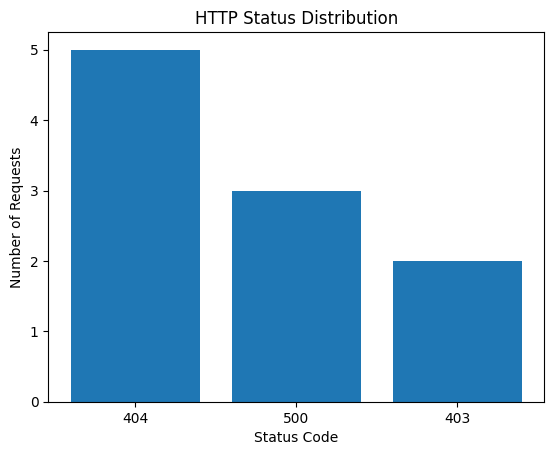

In [18]:
import matplotlib.pyplot as plt

codes = list(reduced.keys())
counts = list(reduced.values())

plt.bar(codes, counts)
plt.title("HTTP Status Distribution")
plt.xlabel("Status Code")
plt.ylabel("Number of Requests")
plt.show()

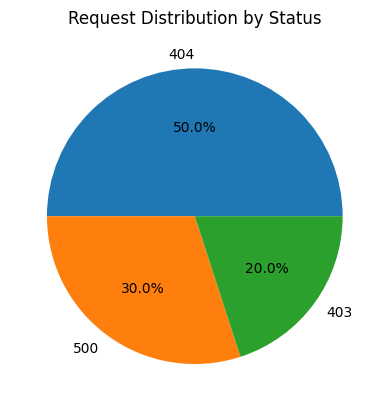

In [19]:
plt.pie(counts, labels=codes, autopct='%1.1f%%')
plt.title("Request Distribution by Status")
plt.show()